# Ribbon model on elastica with Sleeve interaction 
Author: Pierre Maillard *pierre.maillard@epfl.ch*\
Release date: 28.05.2025

This python notebook is a guide to use elastica to simulate the deformation of a 1D ribbon model inside of solide hyperelastic medium as well as the full quasi-static analyis. This notebook assume that you already followed the guide to simulate simple load cases. `Noto_elastica_ribbon_model.ipynb`

The interaction between the ribbon and the medium are computed using an object called a *Sleeve*. Please see **user_guide_ribbon_simulation.pdf** for more details. 

The implementation of the model and all the specific functions related to the ribbon model and medium interaction were hard coded direclty inside of a merge code between the **elastica** source code and a modified version of **elastica** by Arman Tekinalp developped for this work: *Topology, dynamics, and control of a muscle-architected soft arm* (**https://doi.org/10.1073/pnas.2318769121**).\
We use the source code of **elastica** that was available on February 2025 on the *github* page of GazzolaLab: **https://github.com/GazzolaLab/PyElastica** \
And Arman Tekinalp modified version available here: **https://github.com/GazzolaLab/topology-dynamics-control-of-a-muscle-architected-soft-arm** \
As the source-code of elastica has been modified and adapted, **DO NOT** install pyelastica direclty. You should be able to use directly the source code without having to pre-compile/install the **elastica** file as a 'library'.

If you need to change a function related to the behavior of the ribbon or the solver. Go directly inside of the source code of **elastica** available with this notebook and follow the **user_guide_ribbon_simulation.pdf** to find to portion of code you need. Every post-processing and plotting function are define inside of the **src_plotting_ribbon.py** script. All informations related to the flow of data is described on the **user_guide_ribbon_simulation.pdf**.

In [ ]:
#if you need to install the libraries just run this line
#%pip install -U -r requirements.txt

In [1]:
from elastica import *
from elastica.rod.ribbon1D import Ribbon1D
from elastica.rod.linear_ribbon1D import LinearRibbon1D

from elastica._linalg import _batch_norm
from elastica._linalg import _batch_cross

import os
import pickle
import numpy as np
import plotly.graph_objects as go

import plotly.io as pio
pio.renderers.default = "notebook"

import pandas as pd
from collections import defaultdict
from matplotlib import pyplot as plt
from elastica.src_plotting_ribbon import *
from create_sim_env import *

## Relaxation of a ribbon inside of the medium
This section will go through all of the step to run a simulation of the relaxation of a ribbon inside of an hyperelastic medium using elastica. 

### Simulation initialization: Relaxation
Here we apply the same logic as in `Noto_elastica_ribbon_model.ipynb` in the **Simulation initialization: Torsional buckling case** section. This time we start the simulation from a user-define position (and not from the straight ribbon configuration) and add contact with our Sleeve object (see **user_guide_ribbon_simulation.pdf**)\
Because we are now using the reel parameters of the ribbon, the simulations can take a long time to run. Don't hesitate to reduce the `final_time` to small values like 0.01s. This will not allow the simulation to converge to the steady state but can still illustrate nicely how the code works.

In [64]:
class Ribbon(BaseSystemCollection, Contact, Forcing, Constraints, CallBacks, Damping):
        pass
Ribbon_sim = Ribbon()

""" Here we define all of the constants that describ the ribbon material and geometry at the start of the simulation """

start = np.array([0.0, 0.0, 0.0])     #position of the first node
direction = np.array([1.0, 0.0, 0.0]) #direction of the centerline (d3) at the first node
normal = np.array([0.0, 1.0, 0.0])    #normal of the centerline (d1) at the first node

L = 50           # total length [mm]
thickness = 0.1  # thickness [mm] 
width = 5.0      # width [mm]

density = 1.017e-7 # density [g/mm^3] (100 times to havy to stabilize to numerical solver)
nu = 27e1          # damping constant [N*s/mm] (tune to speed up the stabilization of the solution at steady stat)
                   # see user_guide_ribbon_simulation.pdf for details on how to choose an optimized value

E = 2.77e3              # Young's modulus [N/mm^2]
poisson_ratio = 0.34    # Poisson's ratio [-]

num_lagrange = 1e2   # ratio between the stiefness of the centerline (extensibility and shearability) and the stiefness of the bending modes
                     # Try to keep it as high as possible to assure the centerline "inextensibility" and "unshearability"
                     # See the "sanity_check_plot" in the post-processing for more informations.

dt = 3e-8          # time step [s] This needs to be tune by hand to keep stability. (see user_guide_ribbon_simulation.pdf for more informations)
final_time = 0.06  # final time [s] 
                   # The final time of the simulation must be long enough to assure steady stat. 
                   # See the "Sanity and Convergence check" in the post-processing section for more informations.


n_elem = 50  #number of element used to discretize the ribbon



""" Here we define the starting position of the ribbon """
s = np.linspace(0,1,n_elem+1)

#This describe the fonction used to trace the shape of the starting position. 
#Every other quantities (d1,d2,d3) are then derived form the position array
####
w = 2*np.pi
A = 0.1
position = L*np.array([s,np.zeros(n_elem+1),A*np.sin(w*s+np.pi/2)-A])
###

d2 = np.array([np.zeros(n_elem),np.ones(n_elem),np.zeros(n_elem)])
position_diff = position[..., 1:] - position[..., :-1]
rest_lengths = _batch_norm(position_diff)
d3 = position_diff / rest_lengths
d1 = _batch_cross(d2,d3)
d1 = d1 / _batch_norm(d1)
directors = np.stack([d1,d2,d3],axis=0)

""" Add the ribbon object """
ribbon = Ribbon1D.straight_ribbon(
    n_elem,
    np.zeros((3,)),
    d3[:,0],
    d1[:,0],
    L,
    thickness,
    width,
    density,
    youngs_modulus=E,
    shear_modulus=E*num_lagrange, # influence the shearability of the ribbon
    poisson_ratio=0.34,
    position = position,
    directors = directors,
)



Ribbon_sim.append(ribbon)


""" Add damping """
Ribbon_sim.dampen(ribbon).using(
    AnalyticalLinearDamper,
    damping_constant=nu,
    time_step=dt,
)


""" Set up boundary conditions """
#for this case we fix nothing (exept for Y but we dont expect any displacement in this direction) 
#but still let these contrains in the code to let you change them if you need
Ribbon_sim.constrain(ribbon).using(
    GeneralConstraint,
    constrained_position_idx=(0,),
    constrained_director_idx=(0,),
    translational_constraint_selector=np.array([False, True, False]),  # Allow X, fix Y, allow Z movement
    rotational_constraint_selector=np.array([False, False, False])  # Allow all rotations
)


Ribbon_sim.constrain(ribbon).using(
    GeneralConstraint,
    constrained_position_idx=(-1,),
    constrained_director_idx=(-1,),
    #rod_frame_bool = True, #this is my attempt to fix only the displacmenet in the R3 direction ... wich was unsucessfull
    translational_constraint_selector=np.array([False, True, False]),  # Allow X, fix Y, allow Z movement
    rotational_constraint_selector=np.array([False, False, False])  # Allow all rotations
)


""" Set contact """
#create the sleeve object using the initial position and normal direction of the ribbon at initial stat
sleeve = Sleeve(position, d1)

Ribbon_sim.append(sleeve)

Ribbon_sim.detect_contact_between(ribbon, sleeve).using(
    RibbonSleeveContact,
    k=3*1.16e-3,      #k = E_0 = 3*G_0 
    nu=0,             # We don't add any damping comming from the contact.
    alpha = -16.6,    ##Only the AnalyticalLinearDamper should add damping to the simulation
    poisson_ratio=0.5,
    N_quad = 3,      # number of discretization point used to integrate the forces along the width to compute torques
                     # this will slow a lot the simulations so keep it low for debugging 
)


In [65]:
class RibbonCallBack(CallBackBaseClass):
    """
    Call back function for Ribbon object
    """

    def __init__(self, step_skip: int, callback_params: dict):
        CallBackBaseClass.__init__(self)
        self.every = step_skip
        self.callback_params = callback_params

    def make_callback(self, system, time, current_step: int):

        if current_step % self.every == 0:

            self.callback_params["time"].append(time)
            self.callback_params["step"].append(current_step)
            self.callback_params["position"].append(system.position_collection.copy())
            self.callback_params["velocity"].append(system.velocity_collection.copy())
            self.callback_params["curvature"].append(system.kappa.copy())
            self.callback_params["sigma"].append(system.sigma.copy())
            self.callback_params["internal_stress"].append(system.internal_stress.copy())
            self.callback_params["internal_forces"].append(system.internal_forces.copy())
            self.callback_params["external_forces"].append(system.external_forces.copy())
            self.callback_params["internal_couple"].append(system.internal_couple.copy())
            self.callback_params["directors"].append(system.director_collection.copy())
            self.callback_params["dilatation"].append(system.dilatation.copy())
            self.callback_params["tangents"].append(system.tangents.copy())
            
        
            
            return
            
class SleeveCallBack(CallBackBaseClass):
    """
    Call back function for Sleeve object
    """

    def __init__(self, step_skip: int, callback_params: dict):
        CallBackBaseClass.__init__(self)
        self.every = step_skip
        self.callback_params = callback_params

    def make_callback(self, system, time, current_step: int):

        if current_step % self.every == 0:

            self.callback_params["time"].append(time)
            self.callback_params["step"].append(current_step)
            self.callback_params["response_force_sleeve"].append(system.response_force_sleeve.copy())
            self.callback_params["displacement_sleeve"].append(system.displacement_sleeve.copy())
            self.callback_params["response_couple_sleeve"].append(system.response_couple_sleeve.copy())
            self.callback_params["rotation_sleeve"].append(system.rotation_sleeve.copy())
            
            return
            

step_skip= int(final_time/dt/1000)

ribbon_output_list = defaultdict(list)
sleeve_output_list = defaultdict(list)

Ribbon_sim.collect_diagnostics(ribbon).using(
    RibbonCallBack, step_skip=step_skip, callback_params=ribbon_output_list
)

Ribbon_sim.collect_diagnostics(sleeve).using(
    SleeveCallBack, step_skip=step_skip, callback_params=sleeve_output_list
)

In [66]:
Ribbon_sim.finalize()
print("System finalized")

System finalized


In [67]:
timestepper = PositionVerlet() #set the time stepper scheme. Verlet scheme is the default option provided by elastica
total_steps = int(final_time / dt) # The algoritm is run using a for loop so this is the number of step of the loop
nan_detected, end_time = integrate(timestepper, Ribbon_sim, final_time, total_steps, time_display_up = 1)

with open("result/relaxation_demo.pickle", 'wb') as handle:
    pickle.dump(ribbon_output_list, handle, protocol=pickle.HIGHEST_PROTOCOL)

with open("result/relaxation_sleeve_demo.pickle", 'wb') as handle:
    pickle.dump(sleeve_output_list, handle, protocol=pickle.HIGHEST_PROTOCOL)

100%|██████████| 2000000/2000000 [04:38<00:00, 7171.29it/s]


Final time of simulation is :  0.059999999997536184


### Post processing
This part illustrat the post processing of the relaxation simulation. We will not describe the function `plot_multiple_solutions()` and `sanity_check_plot()` in details as it as already been done in `Noto_elastica_ribbon_model.ipynb` and the analysis is very similar. We will focus on the data that we can extract from the sleeve object.

In [68]:
L = 50 # length of the ribbon [mm]

with open("result/relaxation_demo.pickle", 'rb') as handle:
    ribbon_output_list_read = pickle.load(handle)

with open("result/relaxation_sleeve_demo.pickle", 'rb') as handle:
    sleeve_output_list_read = pickle.load(handle)


solution_1 = process_solution_elastica(ribbon_output_list_read, base_length=L)
solution_sleeve = process_solution_elastica_sleeve(sleeve_output_list_read)

#### Standard convergence plots

Here, we create an artificial solution that follow the position of the sleeve to plot it with ribbon on the next visualizations.

This would need to be adapted it you want to plot other quantites from `plot_multiple_solutions` along side the sleeve. Each quantites that you plot need to be defined on both the sleeve solution (*true_solution_sleeve*) and the ribbon solution (*solution_1*). Follow the same logic as the next cell to create the artificial solution if you need.

In [69]:
d = { 's' : s, 
     'X' : position[0,:]/L, 
     'Y' : position[1,:]/L, 
     'Z': position[2,:]/L,
     'R1': np.zeros_like(position[0,:]),
     'R2': np.zeros_like(position[0,:]),
     'R3': np.zeros_like(position[0,:]),
     'VX': np.zeros_like(position[0,:]),
     'VY': np.zeros_like(position[0,:]),
     'VZ': np.zeros_like(position[0,:])
    }
true_solution_sleeve = pd.DataFrame(data = d)
true_solution_sleeve.head()

,s,X,Y,Z,R1,R2,R3,VX,VY,VZ
0,0.00,0.00,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,0.02,0.02,0.0,-0.000789,0.0,0.0,0.0,0.0,0.0,0.0
2,0.04,0.04,0.0,-0.003142,0.0,0.0,0.0,0.0,0.0,0.0
3,0.06,0.06,0.0,-0.007022,0.0,0.0,0.0,0.0,0.0,0.0
4,0.08,0.08,0.0,-0.012369,0.0,0.0,0.0,0.0,0.0,0.0


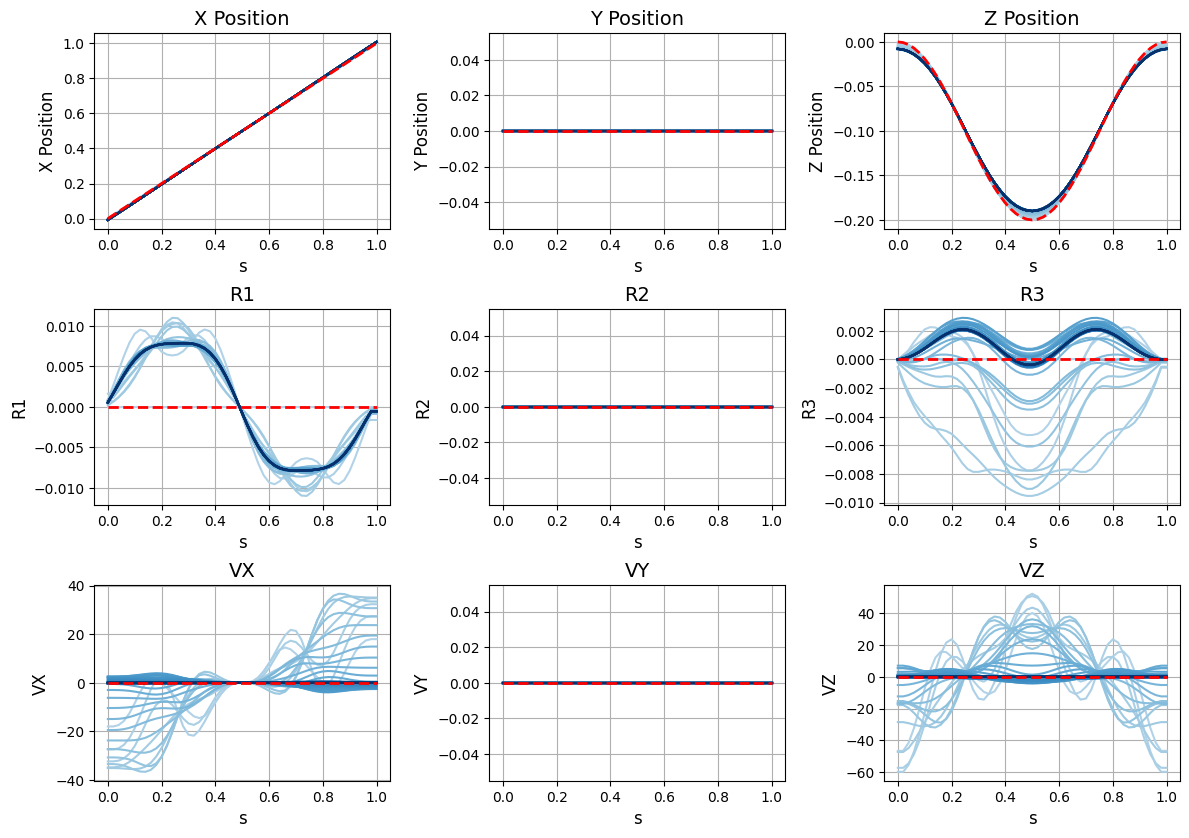

In [70]:
plot_multiple_solutions(
    solution_dfs=[solution_1],true_solution = true_solution_sleeve,
    labels=["Linear Ribbon"],
    indices=np.linspace(0,solution_1.Index_solution.max(),50,dtype=np.int64))

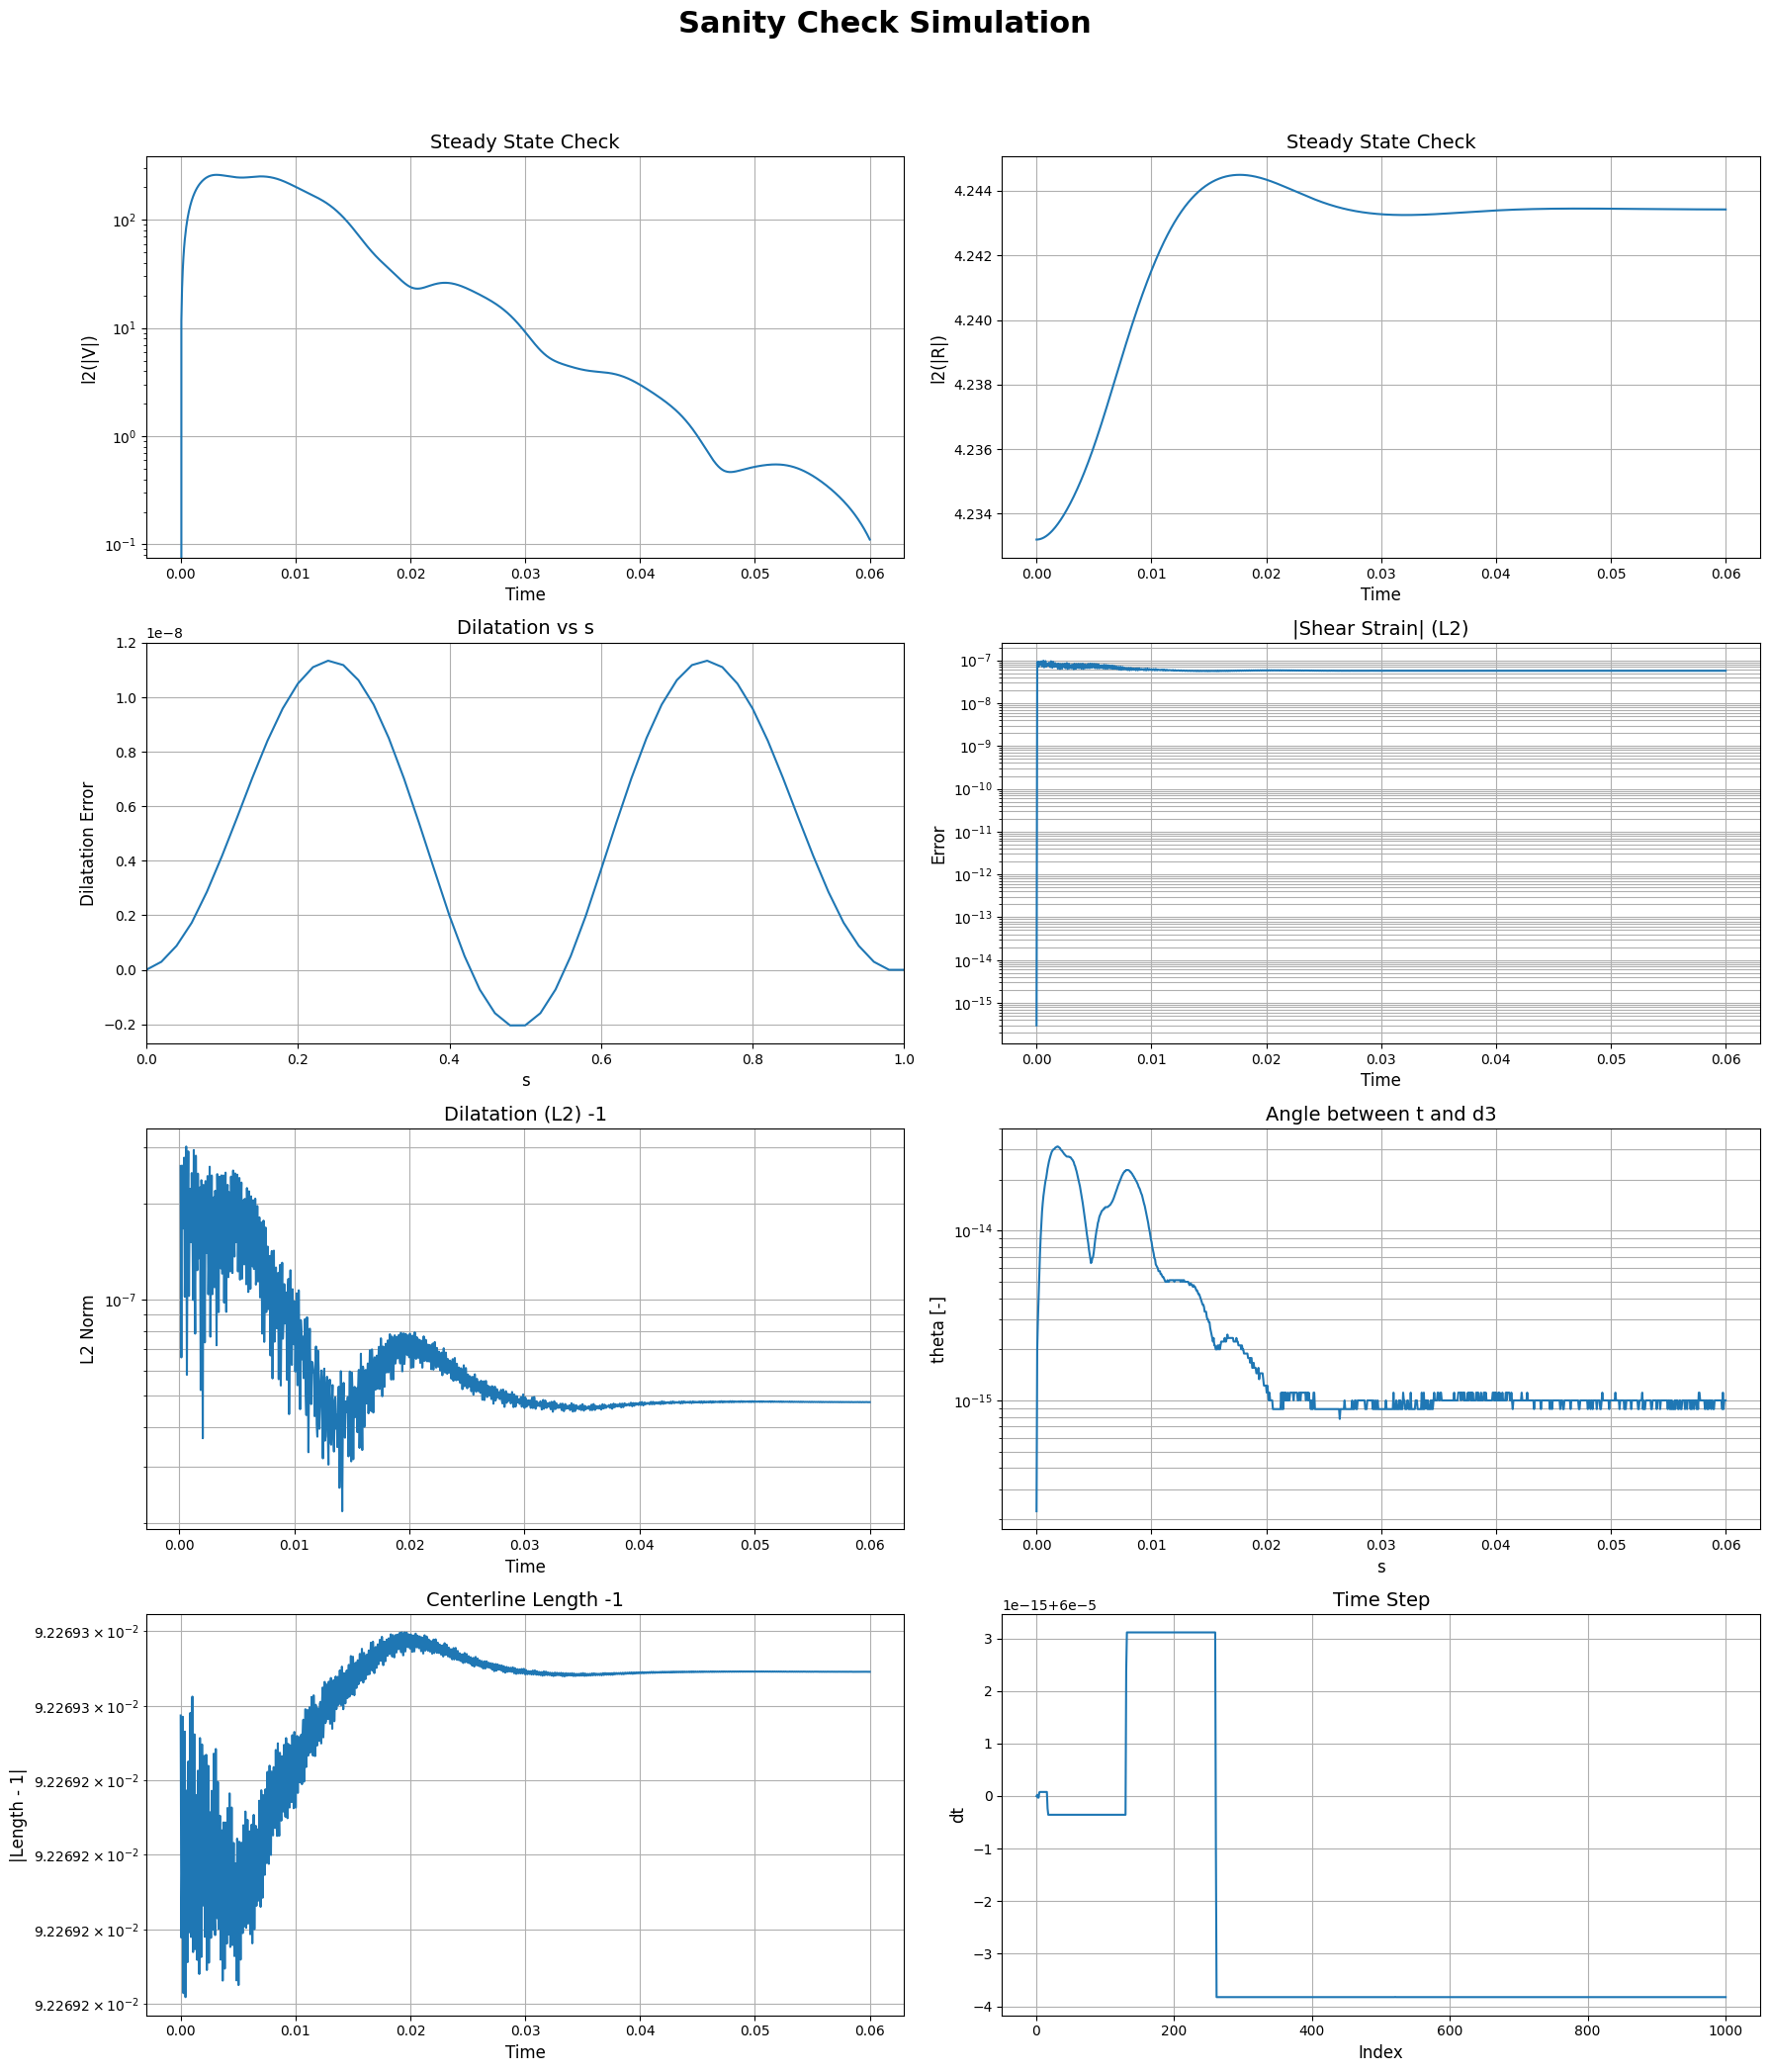

Final stress stat at s = 0:
R1: 5.4265e-04
R2: 0.0000e+00
R3: -3.0701e-07
Final stress stat at s = 1:
R1: -5.4265e-04
R2: 0.0000e+00
R3: 3.3297e-08


In [71]:
sanity_check_plot(solution_1)

In [57]:
#A nice way to create array of indices with more indices near the start of the simulation. 
indices = ((np.logspace(0.0,2,20)*solution_1.Index_solution.max() - solution_1.Index_solution.max())/100).astype(int)

fig = plot_3D_ribbons_from_process_solution(
    solution_1, solution_indices=indices,
    n_arrows = 3,half_width=width/(2*L))

#### Data extracted from the sleeve object
The data extracted using the Callback function of the sleeve inform us on what are the forces and couple that the Sleeve object apply on the ribbon. 
- **Forces :** At each iteration, we compute the displacement (or distance vector) between the centerline of the ribbon and the centerline of the Sleeve. We then project the displacement vector into the d1 (normal) vector of the cosserat frame to compute the force that the medium apply on the ribbon using *hertzian* contact formula. The resulting forces are then project back to the laboratory frame to apply them to each element.
- **Couple**: From the orientation of the d1 (normal) vector, we compute 2 rotation angles on the cosserat frame. The angle around d2 will induce a *bending* response couple and the angle around d3 a *twisting* reponse couple. From these two angles, we compute the displacement respectivelely along the length and width of each element and integrate to get the reponse couple on both direction. We then project these couples on the laboratory frame to apply them to each element

All of the quantities extracted by the Sleeve Callback function are scaled to the global unit system of the simulation so that they can 'interpreted' and used later to reconstruct an estimation of the stress fiel on the surface of the ribbon.

In [72]:
solution_sleeve

,Index_solution,time,step,s,response_force_X,response_force_Y,response_force_Z,displacement_X,displacement_Y,displacement_Z,response_couple_X,response_couple_Y,response_couple_Z,rotation_angle_d1,rotation_angle_d2,rotation_angle_d3
0,0,0.00,0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000e+00,0.0,0.0,0.000000,0.0
1,0,0.00,0,0.020408,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000e+00,0.0,0.0,0.000000,0.0
2,0,0.00,0,0.040816,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000e+00,0.0,0.0,0.000000,0.0
3,0,0.00,0,0.061224,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000e+00,0.0,0.0,0.000000,0.0
4,0,0.00,0,0.081633,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000e+00,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50045,1000,0.06,2000000,0.918367,-0.000312,-0.0,0.000927,-0.343375,0.0,0.275489,0.0,-4.691825e-06,0.0,0.0,-0.049245,-0.0
50046,1000,0.06,2000000,0.938776,-0.000287,-0.0,0.001072,-0.356246,0.0,0.321531,0.0,-3.457524e-06,0.0,0.0,-0.042225,-0.0
50047,1000,0.06,2000000,0.959184,-0.000225,-0.0,0.001161,-0.364231,0.0,0.358426,0.0,-2.055789e-06,0.0,0.0,-0.031251,-0.0
50048,1000,0.06,2000000,0.979592,-0.000138,-0.0,0.001169,-0.367937,0.0,0.382515,0.0,-7.648338e-07,0.0,0.0,-0.016821,-0.0


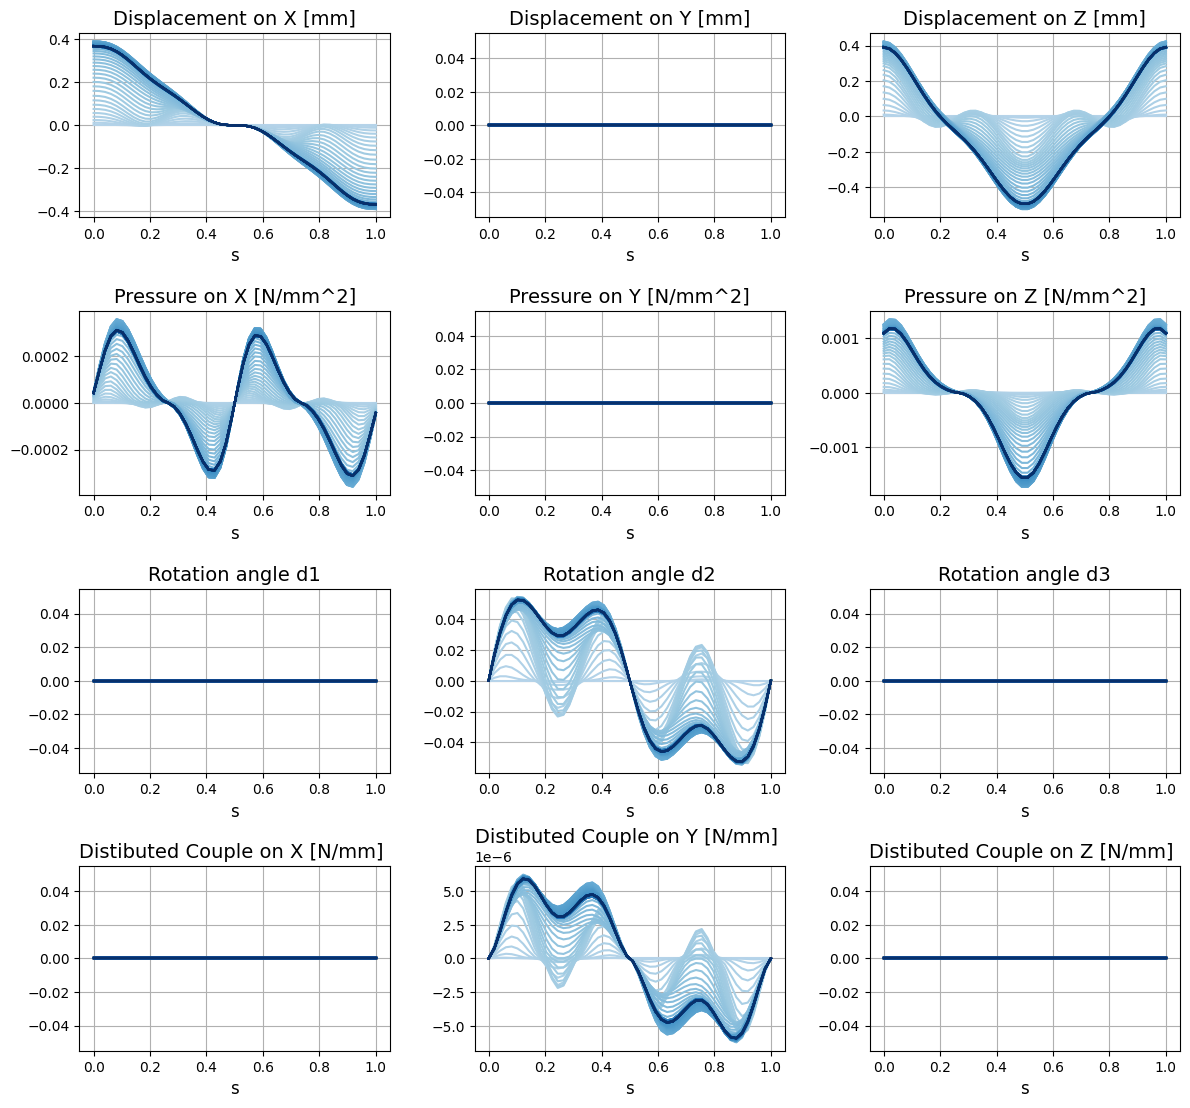

In [73]:
plot_multiple_solutions_sleeve(
    solution_dfs=[solution_sleeve], 
    labels = ["sleeve"], 
    indices = np.linspace(0,solution_sleeve.Index_solution.max(),100,dtype=np.int64))

## Quasi-static simulation: Pushing the ribbon futher inside of the medium
Starting from the same simulation configuration as the relaxation, we will change the boundary conditions, the shape of the sleeeve and the starting position to addapt the system to the Quasi-static simulation case.

For this we can introduce a specific position of the discritization of the path. This code is detailed in `Noto_elastica_full_trajectory.ipynb` and is just used here to extract one quasi static step. Here, we will analyse the 30th quasi-static step.

In [26]:
N_points = 50
direction = np.array([0,-1,0])
normal = np.array([0,0,1])
path_plan = pd.read_csv("path_0_0__15_-20__20_-40.csv")
M = 50 # number of step in a path
min_length = 5
kp = 1.2
final_time = 0.1
paths_points, base_length, normals = build_incremental_discretized_paths(path_plan, direction, normal, N_points, M, min_length)


#here we will analyse the 20th quasi-static step
idx = 30
d1_initial = normals[idx]
initial_position = paths_points[idx] 

sleeve_position = initial_position
d1_sleeve = d1_initial

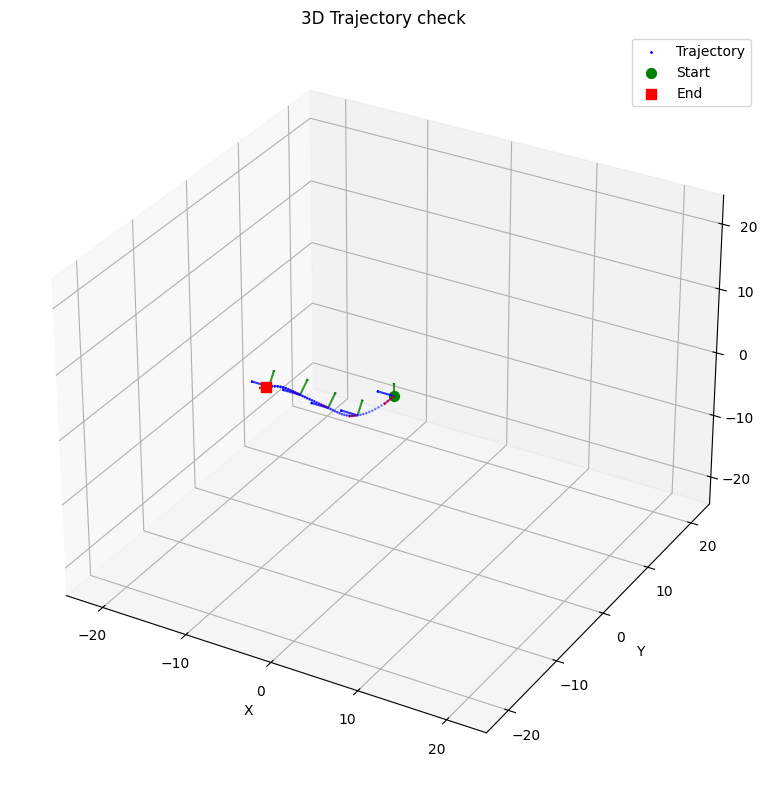

In [27]:
plot_trajectory(initial_position, normal_array = d1_initial,n_frames=5, frame_scale=2)

### Simulation initialization: Quasi-static step

In [28]:
class Ribbon(BaseSystemCollection, Contact, Forcing, Constraints, CallBacks, Damping):
        pass
Ribbon_sim = Ribbon()

""" Here we define all of the constants that describ the ribbon material and geometry at the start of the simulation """

start = np.array([0.0, 0.0, 0.0])     #position of the first node
direction = np.array([1.0, 0.0, 0.0]) #direction of the centerline (d3) at the first node
normal = np.array([0.0, 1.0, 0.0])    #normal of the centerline (d1) at the first node

L = 50           # total length [mm]
thickness = 0.1  # thickness [mm] 
width = 5.0      # width [mm]

density = 1.017e-7 # density [g/mm^3] (100 times to havy to stabilize to numerical solver)
nu = 27e1          # damping constant [N*s/mm] (tune to speed up the stabilization of the solution at steady stat)
                   # see user_guide_ribbon_simulation.pdf for details on how to choose an optimized value

E = 2.77e3              # Young's modulus [N/mm^2]
poisson_ratio = 0.34    # Poisson's ratio [-]

num_lagrange = 1e2   # ratio between the stiefness of the centerline (extensibility and shearability) and the stiefness of the bending modes
                     # Try to keep it as high as possible to assure the centerline "inextensibility" and "unshearability"
                     # See the "sanity_check_plot" in the post-processing for more informations.

dt = 2e-8          # time step [s] This needs to be tune by hand to keep stability. (see user_guide_ribbon_simulation.pdf for more informations)
final_time = 0.1   # final time [s] 
                   # The final time of the simulation must be long enough to assure steady stat. 
                   # See the "Sanity and Convergence check" in the post-processing section for more informations.


n_elem = initial_position.shape[1] - 1  #number of element used to discretize the ribbon

target_force = 0.1    # Amount of force necessary to propagate the crack at the tip [N]
k_p_input_force = 0.8 # Proportional constant used by the P-controller
ramp_up_time = 0.05   # force ramp time [s]



""" Here we define the starting position of the ribbon. This time it is prescribe by the discretization of the trajectory"""

position_diff = initial_position[..., 1:] - initial_position[..., :-1]
rest_lengths = _batch_norm(position_diff)
d3 = position_diff / rest_lengths

d2 = _batch_cross(d3,d1_initial)
d2 = d2 / _batch_norm(d2)

d1 = _batch_cross(d2,d3)
d1 = d1 / _batch_norm(d1)    

directors = np.stack([d1,d2,d3],axis=0)

""" Add the ribbon object """
ribbon = Ribbon1D.straight_ribbon(
    n_elem,
    np.zeros((3,)),
    d3[:,0],
    d1[:,0],
    L,
    thickness,
    width,
    density,
    youngs_modulus=E,
    shear_modulus=E*num_lagrange, # influence the shearability of the ribbon
    poisson_ratio=0.34,
    position = initial_position,
    directors = directors,
)



Ribbon_sim.append(ribbon)


""" Add damping """
Ribbon_sim.dampen(ribbon).using(
    AnalyticalLinearDamper,
    damping_constant=nu,
    time_step=dt,
)


""" Set up boundary conditions """
#for this case we use a slider at the base and a pin a the tip
Ribbon_sim.constrain(ribbon).using(
    GeneralConstraint,
    constrained_position_idx=(0,),
    constrained_director_idx=(0,),
    translational_constraint_selector=np.array([True, False, True]),  # Fix X, allow Y, fix Z movement
    rotational_constraint_selector=np.array([True, True, True])  # Fix all rotations
)


Ribbon_sim.constrain(ribbon).using(
    GeneralConstraint,
    constrained_position_idx=(-1,),
    constrained_director_idx=(-1,),
    #rod_frame_bool = True, #this is my attempt to fix only the displacmenet in the R3 direction ... wich was unsucessfull
    translational_constraint_selector=np.array([True, True, True]),  # fix X, fix Y, fix Z movement
    rotational_constraint_selector=np.array([False, False, False])  # Allow all rotations
)


"""Set the force at the base"""

Ribbon_sim.add_forcing_to(ribbon).using(
        ControledPushForce, target_force, d3[:,0], ramp_up_time, k_p = k_p_input_force
    )


""" Set contact """
#create the sleeve object using the initial position and normal direction of the ribbon at initial stat
sleeve = Sleeve(sleeve_position, d1_initial)

Ribbon_sim.append(sleeve)

Ribbon_sim.detect_contact_between(ribbon, sleeve).using(
    RibbonSleeveContact,
    k=3*1.16e-3,      #k = E_0 = 3*G_0 
    nu=0,             # We don't add any damping comming from the contact.
    alpha = -16.6,    ##Only the AnalyticalLinearDamper should add damping to the simulation
    poisson_ratio=0.5,
    N_quad = 3,      # number of discretization point used to integrate the forces along the width to compute torques
                     # this will slow a lot the simulations so keep it low for debugging 
)


In [29]:
class RibbonCallBack(CallBackBaseClass):
    """
    Call back function for Ribbon object
    """

    def __init__(self, step_skip: int, callback_params: dict):
        CallBackBaseClass.__init__(self)
        self.every = step_skip
        self.callback_params = callback_params

    def make_callback(self, system, time, current_step: int):

        if current_step % self.every == 0:

            self.callback_params["time"].append(time)
            self.callback_params["step"].append(current_step)
            self.callback_params["position"].append(system.position_collection.copy())
            self.callback_params["velocity"].append(system.velocity_collection.copy())
            self.callback_params["curvature"].append(system.kappa.copy())
            self.callback_params["sigma"].append(system.sigma.copy())
            self.callback_params["internal_stress"].append(system.internal_stress.copy())
            self.callback_params["internal_forces"].append(system.internal_forces.copy())
            self.callback_params["external_forces"].append(system.external_forces.copy())
            self.callback_params["internal_couple"].append(system.internal_couple.copy())
            self.callback_params["directors"].append(system.director_collection.copy())
            self.callback_params["dilatation"].append(system.dilatation.copy())
            self.callback_params["tangents"].append(system.tangents.copy())
            
        
            
            return
            
class SleeveCallBack(CallBackBaseClass):
    """
    Call back function for Sleeve object
    """

    def __init__(self, step_skip: int, callback_params: dict):
        CallBackBaseClass.__init__(self)
        self.every = step_skip
        self.callback_params = callback_params

    def make_callback(self, system, time, current_step: int):

        if current_step % self.every == 0:

            self.callback_params["time"].append(time)
            self.callback_params["step"].append(current_step)
            self.callback_params["response_force_sleeve"].append(system.response_force_sleeve.copy())
            self.callback_params["displacement_sleeve"].append(system.displacement_sleeve.copy())
            self.callback_params["response_couple_sleeve"].append(system.response_couple_sleeve.copy())
            self.callback_params["rotation_sleeve"].append(system.rotation_sleeve.copy())
            
            return
            

step_skip= int(final_time/dt/1000)

ribbon_output_list = defaultdict(list)
sleeve_output_list = defaultdict(list)

Ribbon_sim.collect_diagnostics(ribbon).using(
    RibbonCallBack, step_skip=step_skip, callback_params=ribbon_output_list
)

Ribbon_sim.collect_diagnostics(sleeve).using(
    SleeveCallBack, step_skip=step_skip, callback_params=sleeve_output_list
)

In [30]:
Ribbon_sim.finalize()
print("System finalized")

System finalized


In [32]:
timestepper = PositionVerlet() #set the time stepper scheme. Verlet scheme is the default option provided by elastica
total_steps = int(final_time / dt) # The algoritm is run using a for loop so this is the number of step of the loop
nan_detected, end_time = integrate(timestepper, Ribbon_sim, final_time, total_steps, time_display_up = 1)

with open("result/quasi_static_step_demo.pickle", 'wb') as handle:
    pickle.dump(ribbon_output_list, handle, protocol=pickle.HIGHEST_PROTOCOL)

with open("result/quasi_static_step_sleeve_demo.pickle", 'wb') as handle:
    pickle.dump(sleeve_output_list, handle, protocol=pickle.HIGHEST_PROTOCOL)

100%|██████████| 5000000/5000000 [11:27<00:00, 7276.02it/s]


Final time of simulation is :  0.09999999998802997


### Post-processing: Quasi-static step

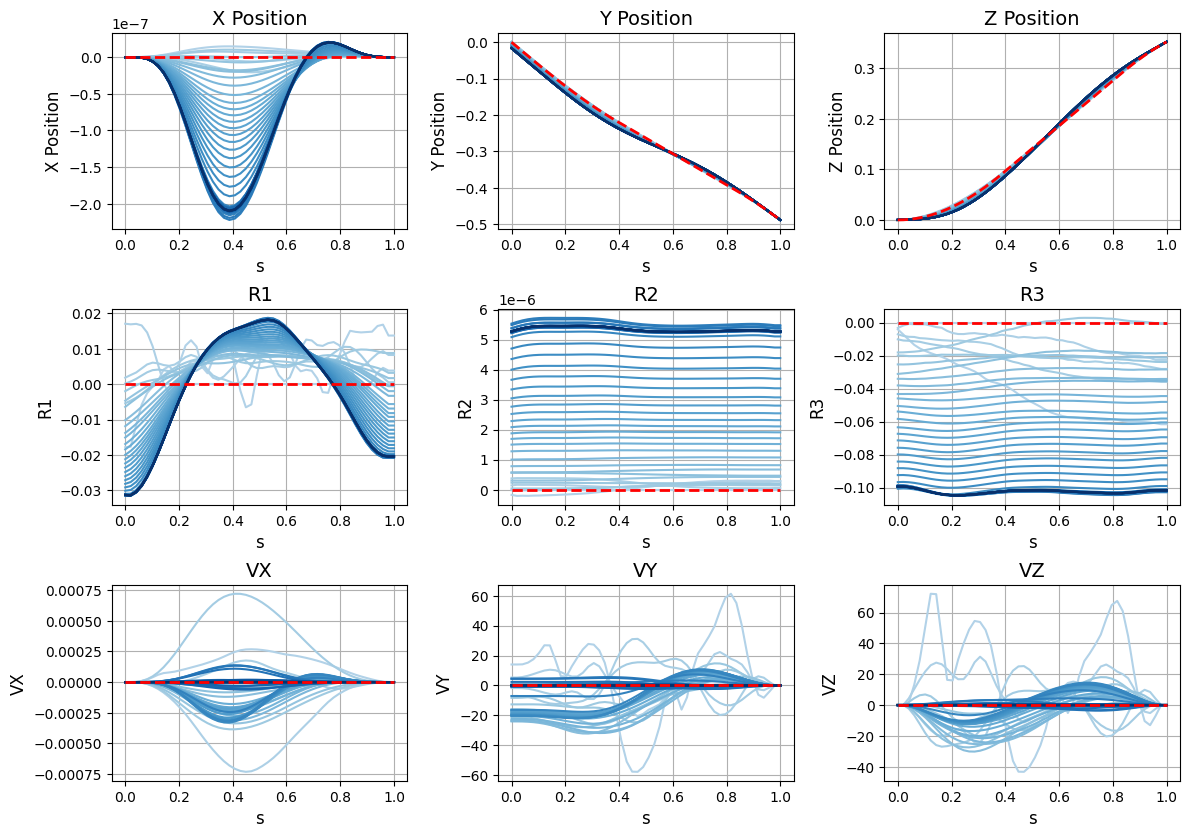

In [43]:
L = 50 # length of the ribbon [mm]

with open("result/quasi_static_step_demo.pickle", 'rb') as handle:
    ribbon_output_list_read = pickle.load(handle)

with open("result/quasi_static_step_sleeve_demo.pickle", 'rb') as handle:
    sleeve_output_list_read = pickle.load(handle)


solution_1 = process_solution_elastica(ribbon_output_list_read, base_length=L)
solution_sleeve = process_solution_elastica_sleeve(sleeve_output_list_read)

s = np.linspace(0,1,initial_position.shape[1])

d = { 's' : s, 
     'X' : initial_position[0,:]/L, 
     'Y' : initial_position[1,:]/L, 
     'Z': initial_position[2,:]/L,
     'R1': np.zeros_like(initial_position[0,:]),
     'R2': np.zeros_like(initial_position[0,:]),
     'R3': np.zeros_like(initial_position[0,:]),
     'VX': np.zeros_like(initial_position[0,:]),
     'VY': np.zeros_like(initial_position[0,:]),
     'VZ': np.zeros_like(initial_position[0,:])
    }
true_solution_sleeve = pd.DataFrame(data = d)
true_solution_sleeve.head()

plot_multiple_solutions(
    solution_dfs=[solution_1],true_solution = true_solution_sleeve,
    labels=["Linear Ribbon"],
    indices=np.linspace(0,solution_1.Index_solution.max(),50,dtype=np.int64))

The `control_law_plot()` plotting function is espacially usefull to check the quality of the Quasi-static step. It allows you to check what is appending with respect to the stress stat at the boundary of the ribbon.

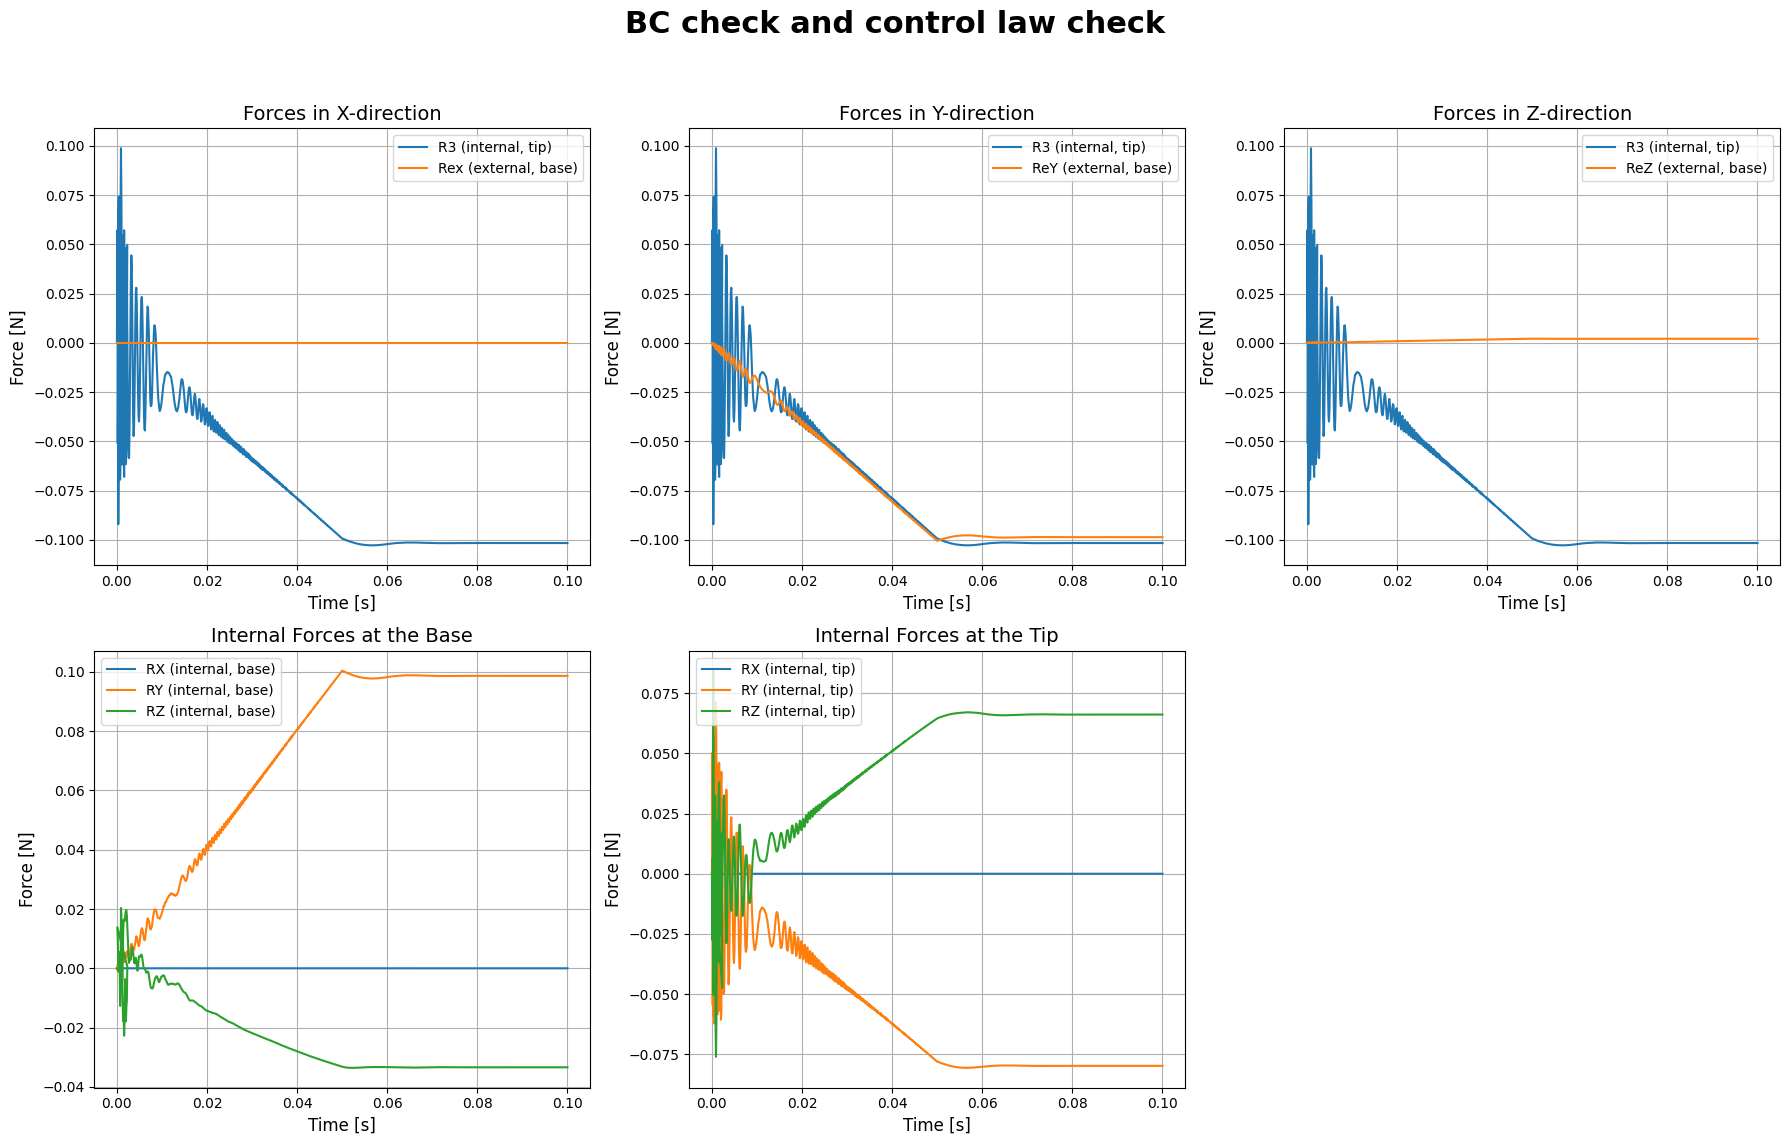

In [44]:
control_law_plot(solution_1)

Here is the more 'Debunging' stage of the data you can get from `control_law_plot()` if needed.

In [74]:
base_sol = solution_1[solution_1.s == 0]
base_sol = base_sol[base_sol.step == base_sol.step.max()]
tip_sol = solution_1[solution_1.s == 1]
tip_sol = tip_sol[tip_sol.step == tip_sol.step.max()]

sleeve_base = solution_sleeve[solution_sleeve.s == 0]
sleeve_base = sleeve_base[sleeve_base.step == sleeve_base.step.max()]

print("Base stress stat:")
print("RX:", base_sol.RX.values[0])
print("RY", base_sol.RY.values[0])
print("RZ", base_sol.RZ.values[0])
print("norm", np.sqrt(base_sol.RX**2 + base_sol.RY**2 + base_sol.RZ**2).values[0], "\n")

print("R1:", base_sol.R1.values[0])
print("R2", base_sol.R2.values[0])
print("R3", base_sol.R3.values[0])
print("norm", np.sqrt(base_sol.R1**2 + base_sol.R2**2 + base_sol.R3**2).values[0], "\n")

print("ReX:", base_sol.ReX.values[0])
print("ReY", base_sol.ReY.values[0])
print("ReZ", base_sol.ReZ.values[0])
print("norm", np.sqrt(base_sol.ReX**2 + base_sol.ReY**2 + base_sol.ReZ**2).values[0], "\n")

print("ReX_sleeve:", sleeve_base.response_force_X.values[0]/2)
print("ReY_sleeve", sleeve_base.response_force_Y.values[0]/2)
print("ReZ_sleeve", sleeve_base.response_force_Z.values[0]/2)
print("norm_sleeve", np.sqrt(sleeve_base.response_force_X**2 + sleeve_base.response_force_Y**2 + sleeve_base.response_force_Z**2).values[0], "\n")


print("Tip stress stat:")
print("RX:", tip_sol.RX.values[0])
print("RY", tip_sol.RY.values[0])
print("RZ", tip_sol.RZ.values[0])
print("norm", np.sqrt(tip_sol.RX**2 + tip_sol.RY**2 + tip_sol.RZ**2).values[0], "\n")

print("R1:", tip_sol.R1.values[0])
print("R2", tip_sol.R2.values[0])
print("R3", tip_sol.R3.values[0])
print("norm", np.sqrt(tip_sol.R1**2 + tip_sol.R2**2 + tip_sol.R3**2).values[0], "\n")

print("ReX:", tip_sol.ReX.values[0])
print("ReY", tip_sol.ReY.values[0])
print("ReZ", tip_sol.ReZ.values[0])
print("norm", np.sqrt(tip_sol.ReX**2 + tip_sol.ReY**2 + tip_sol.ReZ**2).values[0], "\n")

Base stress stat:
RX: -1.5574822642896237e-05
RY 0.09732283124658882
RZ -0.038366954366767056
norm 0.1046124127998618 

R1: -0.03629144517141128
R2 1.5574814408975364e-05
R3 -0.09811562620380299
norm 0.104612357494556 

ReX: 0.0
ReY -0.09731904903561706
ReZ 0.002067223051426413
norm 0.09734100223616554 

ReX_sleeve: 0.0
ReY_sleeve 0.0
ReZ_sleeve 4.65294826158569e-15
norm_sleeve 9.30589652317138e-15 

Tip stress stat:
RX: 1.556681233993996e-05
RY -0.07830906867956847
RZ 0.0725218121779891
norm 0.10673201825772127 

R1: -0.0267565703771763
R2 1.556680367340994e-05
R3 -0.1033237472047932
norm 0.10673195883667728 

ReX: 0.0
ReY -1.1770064579967051e-15
ReZ -2.082556873923458e-15
norm 2.392151194070265e-15 

